In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
import utils_2Q_gate_zp as ut
import qutip as qt
import scqubits as scq
from scipy.ndimage import gaussian_filter
import scipy as sp
from IPython.display import display, Math
from multiprocessing import Pool
import pandas as pd

#### Population transfer

In [2]:
drive_phi, drive_theta = False, True
# drive_phi, drive_theta = True, False
truc1 = 100

folder = '../../data/3ncut_one_zeropi/'
truncation=1000
eval0 = 2*np.pi* scq.read(folder + f'zeropi_0_specdata_truc={truncation}_3ncut.h5').energy_table
n_theta0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_theta_truc={truncation}_3ncut.h5').matrixelem_table
n_phi0 = 2*np.pi* scq.read(folder + f'zeropi_0_n_phi_truc={truncation}_3ncut.h5').matrixelem_table
eval0 = eval0 - eval0[0]
if drive_phi:
    w_trans_1 = eval0[9] - eval0[0]
    w_trans_2 = eval0[9] - eval0[2]
    drive_term = n_phi0
if drive_theta:
    # w_trans_1 = eval0[7] - eval0[0]
    # w_trans_2 = eval0[7] - eval0[2]
    w_trans_1 = eval0[1] - eval0[0]
    w_trans_2 = eval0[2] - eval0[1]
    drive_term = n_theta0

In [ ]:
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [39.991616, 0.105045, 0.028058, 0.002171, 0.003988] # theta state 7
[tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [
                                                      ]   # theta state 1
# [tg, drive_amp_A, drive_amp_B, detune_A, detune_B] = [120.004766,0.209273,0.104767,0.341188,0.360503] # phi
H0 = qt.Qobj(np.diag(eval0))
hilbert_space = np.arange(truc1).tolist()
tlist = np.linspace(0, tg,  num=10* int(tg) )  # total time
pulse_args = {'drive_amp_A': drive_amp_A ,
        'drive_freq_A': w_trans_1 + 2*np.pi*detune_A, #w_trans_1 + 2*np.pi*detune_A,
        'drive_amp_B': drive_amp_B ,
        'drive_freq_B': w_trans_2 + 2*np.pi*detune_B,
        'gate_time': tg,
        }

H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drive_gauss_A],
                        [drive_truc, ut.drive_gauss_B],]
states = [qt.basis(truc1, i) for i in range(truc1)]

result = {}
logi_state = [0, 2]
logi_index = [hilbert_space.index(i) for i in logi_state]
for jdx, state_j in enumerate(logi_index):
    result[jdx] = qt.mesolve(
        H_qbt_drive,
        states[state_j],
        tlist,
        e_ops=[state * state.dag() for state in states],
        args=pulse_args,
        options=qt.Options(store_states=True, nsteps=1e4)  )

Text(0, 0.5, 'Population')

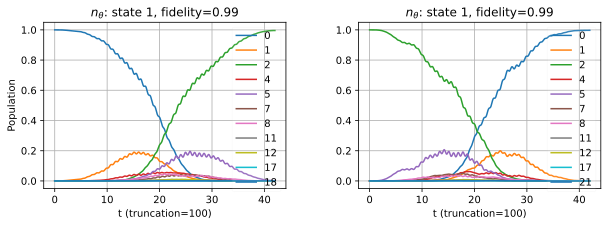

In [9]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
state_phi = [0, 2, 9, 10, 19, 33, 37, 47] # phi
state_theta = [0, 2, 7, 25] # theta
state_interest = state_theta if drive_theta else state_phi
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        # if state in state_interest:
        pop = gaussian_filter( np.array(res).flatten(), 3)
        if np.max(pop) > 0.001:
            ax[jdx].plot(tlist, pop, label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    # ax[jdx].set_ylim(-0.001,0.12)
    ax[jdx].grid()
    ax[jdx].legend().get_frame().set_alpha(0.1)
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    ax[jdx].set_title(f'$n_\\theta$: state 1, fidelity=0.99')
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
# handles, labels = ax[0].get_legend_handles_labels()
# ax[0].legend( handles[::-1],labels[::-1], ncol=8,
#             loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

In [8]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

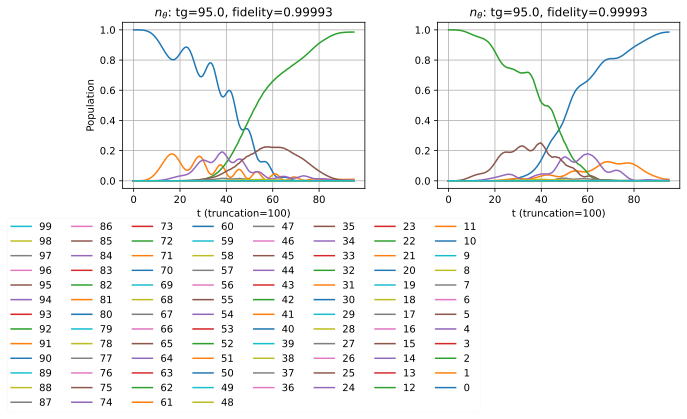

In [ ]:
#####################################################################################
##### Drive and Population Visualization #######
fig, ax = plt.subplots(figsize=(10,3), nrows=1, ncols=2)
#ax[0].plot(tlist_se, drive)
# fig.suptitle('with drag: fidelity=%.8f'%fidelity_real[0])
plt.subplots_adjust(wspace=0.3, hspace=0.3)
order = ['(a)', '(b)','(c)','(d)']
for jdx, state_j in enumerate(logi_state):
    for state, res in enumerate(result[jdx].expect):
        # if state in state_interest:
        ax[jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) , label=r"%d"%hilbert_space[state])
        # ax[jdx].plot(tlist_se, np.array(res).flatten(), label=r"%d"%hilbert_space[state])
    # ax[jdx].set_ylim(-0.001,0.12)
    ax[jdx].grid()
    ax[jdx].set_xlabel(f't (truncation={truc1})')
    ax[jdx].set_title(f'$n_\\theta$: tg={np.round(tg,1)}, fidelity=0.99')
    # ax[jdx].set_title('initial state=|'+str(state_i)+str(state_j)+'>')
    # ax[idx][jdx].text(0.05, 0.93, order[2*idx+jdx], transform=ax[idx][jdx].transAxes,  va='top')
ax[0].set_ylabel('Population')
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend( handles[::-1],labels[::-1], ncol=8,
            loc='upper center', bbox_to_anchor=(0.5, -0.15)).get_frame().set_alpha(0.1)

In [ ]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

In [ ]:
pop = np.array(result[0].expect)
print(np.shape(pop))
pop_integral = pop.sum(axis=1)
print(np.shape(pop_integral))

(100, 1200)
(100,)


In [ ]:

# Example NumPy array
arr = pop_integral

# Get the indices of the top 10 largest values
top_indices = np.argsort(arr)[-20:]  # Sort and take the last 10 indices

# Get the top 10 largest values
top_values = arr[top_indices]

# Sorting in descending order (optional)
sorted_order = np.argsort(top_values)[::-1]
top_indices = top_indices[sorted_order]
top_values = top_values[sorted_order]

print("Top 10 values:", top_values.tolist())
print("State of large population:", top_indices.tolist())


Top 10 values: [536.7426346882427, 464.62107963799406, 49.15375992352576, 44.31839240867677, 36.54479054212087, 25.80413264135733, 11.092087366299413, 7.088375232925662, 3.447575546080623, 2.875881356380311, 2.87424863811283, 2.098440201544163, 1.6665115718810155, 1.488242527346707, 1.4742892187864425, 1.359625387768136, 1.0506113516559124, 0.8889950235378652, 0.882588776100109, 0.5740066505302972]
State of large population: [2, 0, 9, 19, 10, 33, 47, 37, 15, 57, 42, 23, 25, 28, 40, 70, 69, 83, 31, 51]


In [ ]:
pop = np.array(result[0].expect)
pop_interest = pop[state_interest, :]
pop_other = np.delete(pop, state_interest, axis=0).sum(axis=0)
pop_save = np.vstack((tlist,pop_interest, pop_other)).T
col_phi = ['tg'] + [f'{i}' for i in state_phi] + ['other']
col_theta = ['tg'] + [f'{i}' for i in state_theta] + ['other']
columns = col_theta if drive_theta else col_phi
df = pd.DataFrame(pop_save, columns=columns)
# df.to_csv('data/population_theta.txt', sep=',', index=False, header=True)

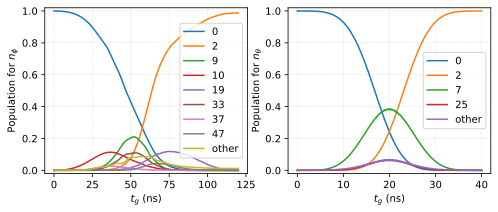

In [ ]:
from scipy.ndimage import gaussian_filter
pop_phi = pd.read_csv('data/population_phi.txt').to_numpy()
pop_theta = pd.read_csv('data/population_theta.txt').to_numpy()

col_phi = ['tg'] + [f'{i}' for i in state_phi] + ['other']
col_theta = ['tg'] + [f'{i}' for i in state_theta] + ['other']

x_size, y_size = 8, 3
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(x_size, y_size))
# plt.subplots_adjust(wspace=0.5)
for i in np.arange(1, pop_phi.shape[1]):
    ax[0].plot( pop_phi[:,0], gaussian_filter( pop_phi[:,i], 3), '-', label=col_phi[i])
for i in np.arange(1, pop_theta.shape[1]):
    ax[1].plot( pop_theta[:,0], gaussian_filter( pop_theta[:,i], 3), '-', label=col_theta[i])
ax[0].set_ylabel(r'Population for $n_\phi$')
ax[1].set_ylabel(r'Population for $n_\theta$')

for i in range(2):
    # ax[i].set_xlim(-25, 25)
    ax[i].set_ylim(-0.02, 1.02)
    ax[i].legend()
    ax[i].grid(linewidth=0.2, linestyle='--')
    ax[i].set_xlabel(r'$t_g$ (ns)')



In [ ]:
=

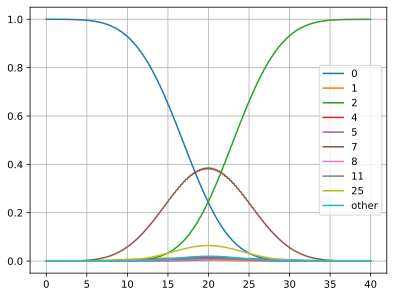

In [ ]:
df_import = pd.read_csv('data/population_theta.txt').to_numpy()
for i in np.arange(1, df_import.shape[1]):
    plt.plot(df_import[:,0], gaussian_filter( df_import[:,i], 3), label=col_theta[i] )
plt.legend()
plt.grid()
